In [ ]:
!pip install statsbombpy mplsoccer --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 708.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from statsbombpy import sb
from mplsoccer import VerticalPitch

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {'gol': '#e63946', 'no_gol': '#457b9d', 'neutral': '#2E4057'}

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [ ]:
competitions = sb.competitions()

# Las 3 competiciones seleccionadas y temporadas desde 2003/04
# Se excluyen temporadas historicas (años 70-90) por falta de representatividad
competiciones = competitions[
    (competitions['competition_id'].isin([11, 16, 43])) &
    (competitions['season_name'].apply(lambda x: int(x[:4]) >= 2003))
][['competition_id', 'competition_name', 'season_id', 'season_name']]

print(f'Temporadas seleccionadas: {len(competiciones)}')
print(competiciones[['competition_name','season_name']].to_string(index=False))

Temporadas seleccionadas: 33
competition_name season_name
Champions League   2018/2019
Champions League   2017/2018
Champions League   2016/2017
Champions League   2015/2016
Champions League   2014/2015
Champions League   2013/2014
Champions League   2012/2013
Champions League   2011/2012
Champions League   2010/2011
Champions League   2009/2010
Champions League   2008/2009
Champions League   2006/2007
Champions League   2004/2005
Champions League   2003/2004
  FIFA World Cup        2022
  FIFA World Cup        2018
         La Liga   2020/2021
         La Liga   2019/2020
         La Liga   2018/2019
         La Liga   2017/2018
         La Liga   2016/2017
         La Liga   2015/2016
         La Liga   2014/2015
         La Liga   2013/2014
         La Liga   2012/2013
         La Liga   2011/2012
         La Liga   2010/2011
         La Liga   2009/2010
         La Liga   2008/2009
         La Liga   2007/2008
         La Liga   2006/2007
         La Liga   2005/2006
         La Li

En el primer paso se identifican las competiciones y temporadas disponibles en el repositorio StatsBomb Open Data. De las 24 competiciones disponibles, se seleccionan únicamente tres: La Liga española, la UEFA Champions League y la Copa del Mundo FIFA, por ser las que combinan mayor volumen de datos, relevancia deportiva y cobertura histórica. Se aplica además un filtro temporal para conservar solo temporadas a partir de 2003/04, excluyendo datos históricos de décadas anteriores que no son representativos del fútbol contemporáneo. El resultado es un total de 33 temporadas seleccionadas: 17 de La Liga (2004/05 a 2020/21), 14 de Champions League (2003/04 a 2018/19) y 2 de Copa del Mundo (2018 y 2022).

In [ ]:
def cargar_disparos(competition_id, season_id, competition_name):
    """
    Descarga todos los eventos de tipo Shot de una temporada.
    Añade columnas de identificacion de competicion y temporada.
    """
    try:
        matches = sb.matches(competition_id=competition_id, season_id=season_id)
        all_shots = []
        for match_id in matches['match_id']:
            events = sb.events(match_id=match_id)
            shots = events[events['type'] == 'Shot'].copy()
            if not shots.empty:
                shots['competition'] = competition_name
                shots['season_id']   = season_id
                shots['match_id']    = match_id
                all_shots.append(shots)
        if all_shots:
            return pd.concat(all_shots, ignore_index=True)
    except Exception as e:
        print(f'  Error en {competition_name} temporada {season_id}: {e}')
    return pd.DataFrame()

print('Funcion de descarga definida.')

Funcion de descarga definida.


Se define una función reutilizable que automatiza la descarga de datos partido a partido. Para cada temporada, la función busca los partidos disponibles y selecciona solo los eventos relacionados con disparos a puerta. Además, añade información sobre la competición y la temporada para ayudar a comparar los datos después. También incluye una forma de manejar errores, de modo que si en alguna descarga hay un problema, el proceso siga adelante sin detenerse. Al final, la función está lista para usarse con las 33 temporadas que se eligieron anteriormente.

In [ ]:
print(f'Iniciando descarga de {len(competiciones)} temporadas...\n')

all_shots_list = []
for _, row in competiciones.iterrows():
    print(f'  -> {row["competition_name"]} - {row["season_name"]}')
    shots_temp = cargar_disparos(row['competition_id'], row['season_id'], row['competition_name'])
    if not shots_temp.empty:
        all_shots_list.append(shots_temp)

df_raw = pd.concat(all_shots_list, ignore_index=True)
print(f'\nDescarga completada.')
print(f'   Total disparos descargados: {len(df_raw):,}')
print(f'   Columnas disponibles:       {df_raw.shape[1]}')

Iniciando descarga de 33 temporadas...

  -> Champions League - 2018/2019
  -> Champions League - 2017/2018
  -> Champions League - 2016/2017
  -> Champions League - 2015/2016
  -> Champions League - 2014/2015
  -> Champions League - 2013/2014
  -> Champions League - 2012/2013
  -> Champions League - 2011/2012
  -> Champions League - 2010/2011
  -> Champions League - 2009/2010
  -> Champions League - 2008/2009
  -> Champions League - 2006/2007
  -> Champions League - 2004/2005
  -> Champions League - 2003/2004
  -> FIFA World Cup - 2022
  -> FIFA World Cup - 2018
  -> La Liga - 2020/2021
  -> La Liga - 2019/2020
  -> La Liga - 2018/2019
  -> La Liga - 2017/2018
  -> La Liga - 2016/2017
  -> La Liga - 2015/2016
  -> La Liga - 2014/2015
  -> La Liga - 2013/2014
  -> La Liga - 2012/2013
  -> La Liga - 2011/2012
  -> La Liga - 2010/2011
  -> La Liga - 2009/2010
  -> La Liga - 2008/2009
  -> La Liga - 2007/2008
  -> La Liga - 2006/2007
  -> La Liga - 2005/2006
  -> La Liga - 2004/2005

Desc

Se aplica la función de descarga sobre las 33 temporadas seleccionadas. Se obtienen un total de 24.809 disparos repartidos entre Champions League, Copa del Mundo y La Liga. Cada fila representa un disparo individual con 122 atributos asociados.

In [ ]:
GOAL_X, GOAL_Y = 120, 40
GOAL_POST_Y1, GOAL_POST_Y2 = 36, 44

columnas = [
    'id', 'match_id', 'competition', 'season_id', 'minute', 'player',
    'team', 'location', 'shot_outcome', 'shot_type', 'shot_body_part',
    'shot_technique', 'shot_statsbomb_xg', 'under_pressure', 'shot_first_time'
]
columnas_ok = [c for c in columnas if c in df_raw.columns]
df = df_raw[columnas_ok].copy()

# Extraer coordenadas x e y
df['x'] = df['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
df['y'] = df['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
df.drop(columns=['location'], inplace=True)

# Excluir penaltis
df = df[df['shot_type'] != 'Penalty'].copy()

# Variable objetivo
df['gol'] = (df['shot_outcome'] == 'Goal').astype(int)

# Distancia al gol
df['shot_distance'] = np.sqrt((df['x'] - GOAL_X)**2 + (df['y'] - GOAL_Y)**2)

# Angulo de disparo
def calcular_angulo(x, y):
    a = np.array([x - GOAL_X, y - GOAL_POST_Y1])
    b = np.array([x - GOAL_X, y - GOAL_POST_Y2])
    cos_angle = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

df['shot_angle'] = df.apply(lambda row: calcular_angulo(row['x'], row['y']), axis=1)

# Limpiar categoricas
for col in ['shot_outcome', 'shot_type', 'shot_body_part', 'shot_technique']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Booleanas: NaN = False
for col in ['under_pressure', 'shot_first_time']:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)

print(f'Dataset construido.')
print(f'   Disparos totales (sin penaltis): {len(df):,}')
print(f'   Goles: {df["gol"].sum():,} ({df["gol"].mean()*100:.1f}%)')
print(f'   Columnas: {df.shape[1]}')
df.head()

Dataset construido.
   Disparos totales (sin penaltis): 24,399
   Goles: 2,788 (11.4%)
   Columnas: 19


,id,match_id,competition,season_id,minute,player,team,shot_outcome,shot_type,shot_body_part,shot_technique,shot_statsbomb_xg,under_pressure,shot_first_time,x,y,gol,shot_distance,shot_angle
1,67b9cbde-0eb7-4800-9bfe-c2ce1ad406a6,22912,Champions League,4,9,Moussa Sissoko,Tottenham Hotspur,Off T,Open Play,Right Foot,Normal,0.0262,1,0,91.9000,43.1000,0,28.2705,16.0146
2,08c3746b-a125-4adb-991e-c8053578451a,22912,Champions League,4,16,Trent Alexander-Arnold,Liverpool,Off T,Open Play,Right Foot,Normal,0.0062,0,0,90.2000,59.3000,0,35.5039,10.8441
3,8fb3106d-10fb-42c6-bcf6-2ea34c7ff9a3,22912,Champions League,4,20,Mohamed Salah,Liverpool,Blocked,Open Play,Left Foot,Normal,0.0398,0,0,95.2000,47.2000,0,25.8240,16.9522
4,4004264d-14a1-4e0d-b01d-a5d025e26c17,22912,Champions League,4,21,Mohamed Salah,Liverpool,Wayward,Open Play,Left Foot,Normal,0.0071,0,0,113.0000,59.5000,0,20.7183,7.7172
5,ac439699-4dde-42dd-9f67-dd9ef6b6e885,22912,Champions League,4,37,Andrew Robertson,Liverpool,Saved,Open Play,Left Foot,Normal,0.0092,0,0,98.4000,20.4000,0,29.1671,11.6959


A partir de los datos se construye el dataset de trabajo seleccionando solo las variables relevantes para el modelo. Después de quitar los penaltis, quedan 24.399 tiros, de los cuales 2.788 terminaron en gol, lo que representa aproximadamente el 11.4%. Además, se añaden nuevas informaciones sobre la distancia y el ángulo de cada tiro, que se calculan a partir de las posiciones de donde se disparó.

In [ ]:
missing = pd.DataFrame({
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct_missing', ascending=False)

missing_positivos = missing[missing['n_missing'] > 0]
print('Variables con valores ausentes:')
if missing_positivos.empty:
    print('  -> No hay valores ausentes en las variables de modelizacion.')
else:
    print(missing_positivos.to_string())

Variables con valores ausentes:
  -> No hay valores ausentes en las variables de modelizacion.


Se comprueba si hay valores que faltan en las variables de modelización. La revisión muestra que no falta ninguno, por lo que el conjunto de datos está completo y no hace falta rellenar ningún valor para las variables importantes del modelo.

In [ ]:
vars_numericas = ['shot_distance', 'shot_angle', 'minute', 'shot_statsbomb_xg']
vars_numericas = [v for v in vars_numericas if v in df.columns]

desc = df[vars_numericas].describe().T
desc['skewness'] = df[vars_numericas].skew().round(3)
print('Estadisticas descriptivas:')
print(desc.round(3).to_string())

Estadisticas descriptivas:
                       count    mean     std    min     25%     50%     75%      max  skewness
shot_distance     24399.0000 19.1800  8.6890 0.4000 12.2990 18.3580 25.3300  81.4440    0.7170
shot_angle        24399.0000 24.9730 15.6170 0.0060 14.9410 19.5320 30.1630 179.9800    2.3680
minute            24399.0000 48.7070 26.8100 0.0000 26.0000 49.0000 71.0000 123.0000   -0.0270
shot_statsbomb_xg 24399.0000  0.1020  0.1300 0.0000  0.0290  0.0570  0.1130   0.9930    2.9810


Se calculan las principales estadísticas de las variables numéricas clave. La distancia promedio de los disparos es de 19.2 unidades, con valores que van desde casi 0 hasta 81.4, lo que muestra que hay muchas maneras diferentes en que se hacen los disparos. El valor promedio de la probabilidad de gol (xG) de StatsBomb es de 0.10, lo que significa que, en promedio, solo uno de cada diez disparos termina en gol. La forma en que se distribuyen los datos, llamada asimetría positiva, indica que la mayoría de los disparos se realizan desde lugares cercanos a la portería y con ángulos bajos.

In [ ]:
resumen = df.groupby('competition').agg(
    n_disparos=('gol', 'count'),
    n_goles=('gol', 'sum'),
    tasa_conversion=('gol', 'mean'),
    distancia_media=('shot_distance', 'mean'),
    angulo_medio=('shot_angle', 'mean'),
    xg_medio=('shot_statsbomb_xg', 'mean')
).round(3)
resumen['tasa_conversion'] = (resumen['tasa_conversion'] * 100).round(1)
print('Resumen por competicion:')
print(resumen.to_string())

Resumen por competicion:
                  n_disparos  n_goles  tasa_conversion  distancia_media  angulo_medio  xg_medio
competition                                                                                    
Champions League         423       44          10.4000          20.1730       24.9350    0.0890
FIFA World Cup          3068      287           9.4000          18.9250       25.5860    0.0940
La Liga                20908     2457          11.8000          19.1970       24.8830    0.1030


Se analiza cómo se realizan los disparos en tres diferentes competiciones. La Liga tiene la mayor cantidad de tiros, con 20.908, y de esos, aproximadamente uno de cada nueve termina en gol, con una tasa de conversión del 11.8%. Esto es un poco mejor que en la Liga de Campeones, que tiene una tasa del 10.4%, y la Copa del Mundo, con un 9.4%. Las posiciones y ángulos desde donde se hacen los disparos son similares en las diferentes competiciones, por lo que las diferencias en cuántos goles se logran parecen estar más relacionadas con la dificultad que ponen los defensores que con el lugar desde donde se dispara.

No gol: 21,611 (88.6%)
Gol:    2,788 (11.4%)
Ratio desbalance: 7.8:1


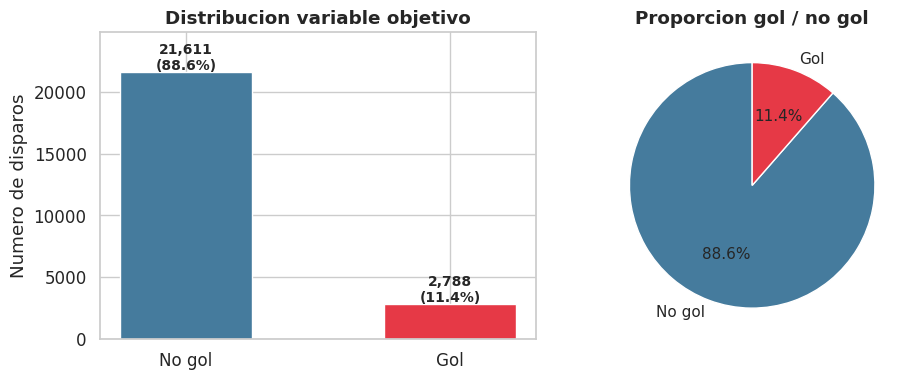

In [ ]:
conteo = df['gol'].value_counts()
pct = df['gol'].value_counts(normalize=True) * 100

print(f'No gol: {conteo[0]:,} ({pct[0]:.1f}%)')
print(f'Gol:    {conteo[1]:,} ({pct[1]:.1f}%)')
print(f'Ratio desbalance: {conteo[0]/conteo[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bars = axes[0].bar(['No gol','Gol'], [conteo[0], conteo[1]],
                   color=[COLORS['no_gol'], COLORS['gol']], edgecolor='white', width=0.5)
for bar, val, p in zip(bars, [conteo[0],conteo[1]], [pct[0],pct[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribucion variable objetivo', fontweight='bold')
axes[0].set_ylabel('Numero de disparos')
axes[0].set_ylim(0, max(conteo[0], conteo[1]) * 1.15)
axes[1].pie([conteo[0], conteo[1]], labels=['No gol','Gol'],
            colors=[COLORS['no_gol'], COLORS['gol']],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporcion gol / no gol', fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

El dataset presenta un claro desbalance: hay 21.611 tiros que no lograron marcar un gol (88,6%) y solo 2.788 que sí lo lograron (11,4%), lo que significa que por cada gol hay aproximadamente 8 tiros que no terminan en gol. Esto es algo muy común en el fútbol, ya que la mayoría de los tiros no terminan en gol. Por eso, se usará la métrica llamada AUC-ROC para evaluar el rendimiento del modelo, ya que es una forma confiable incluso cuando los datos están desequilibrados.

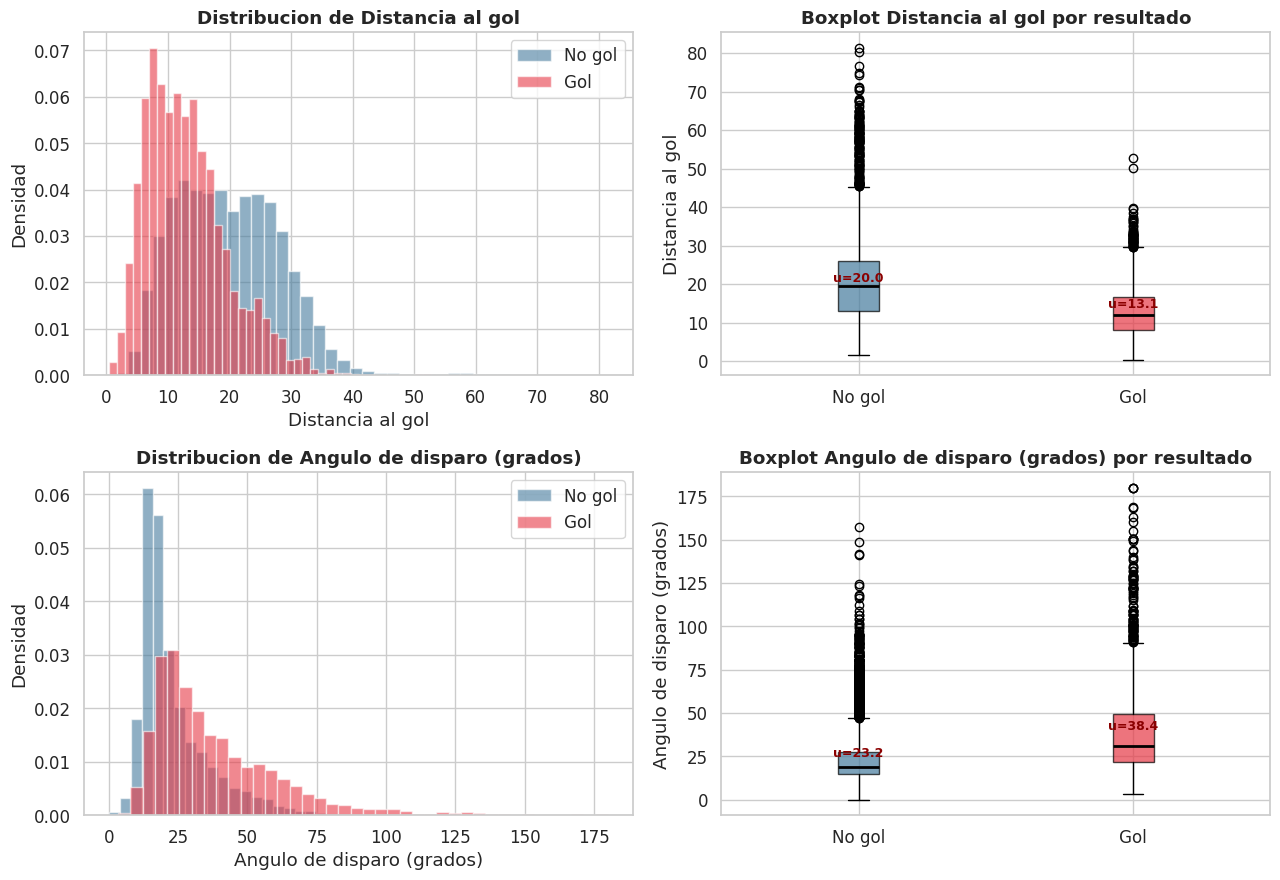

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
vars_plot = [('shot_distance','Distancia al gol'), ('shot_angle','Angulo de disparo (grados)')]

for i, (var, label) in enumerate(vars_plot):
    for val, color, name in [(0, COLORS['no_gol'],'No gol'),(1, COLORS['gol'],'Gol')]:
        axes[i,0].hist(df[df['gol']==val][var].dropna(),
                       bins=40, alpha=0.6, color=color, label=name, density=True)
    axes[i,0].set_xlabel(label)
    axes[i,0].set_ylabel('Densidad')
    axes[i,0].set_title(f'Distribucion de {label}', fontweight='bold')
    axes[i,0].legend()

    data_box = [df[df['gol']==0][var].dropna(), df[df['gol']==1][var].dropna()]
    bp = axes[i,1].boxplot(data_box, labels=['No gol','Gol'], patch_artist=True,
                           medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor(COLORS['no_gol'])
    bp['boxes'][1].set_facecolor(COLORS['gol'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    axes[i,1].set_ylabel(label)
    axes[i,1].set_title(f'Boxplot {label} por resultado', fontweight='bold')
    for j, val in enumerate([0,1]):
        m = df[df['gol']==val][var].mean()
        axes[i,1].text(j+1, m, f'u={m:.1f}', ha='center', va='bottom',
                       fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_distancia_angulo.png', dpi=150, bbox_inches='tight')
plt.show()

Los gráficos muestran claramente lo que ya se había visto en las estadísticas: los goles suelen hacerse desde más cerca del arco, con una distancia promedio de 13.1 metros, mientras que los tiros que no terminaron en gol tenían una distancia mayor, de unos 20 metros. También pasa lo mismo con el ángulo de disparo: los goles generalmente se generan desde ángulos más cerrados, con una media de 38.4 grados, mientras que los tiros sin gol tenían ángulos más abiertos, de unos 23.2 grados. Esto quiere decir que los tiros que van más al centro y desde cerca tienen más posibilidades de ser goles. Ambas cosas, la distancia y el ángulo, muestran claramente que influyen en si un tiro va a terminar en gol o no, y por eso son importantes para predecir los resultados en el modelo.

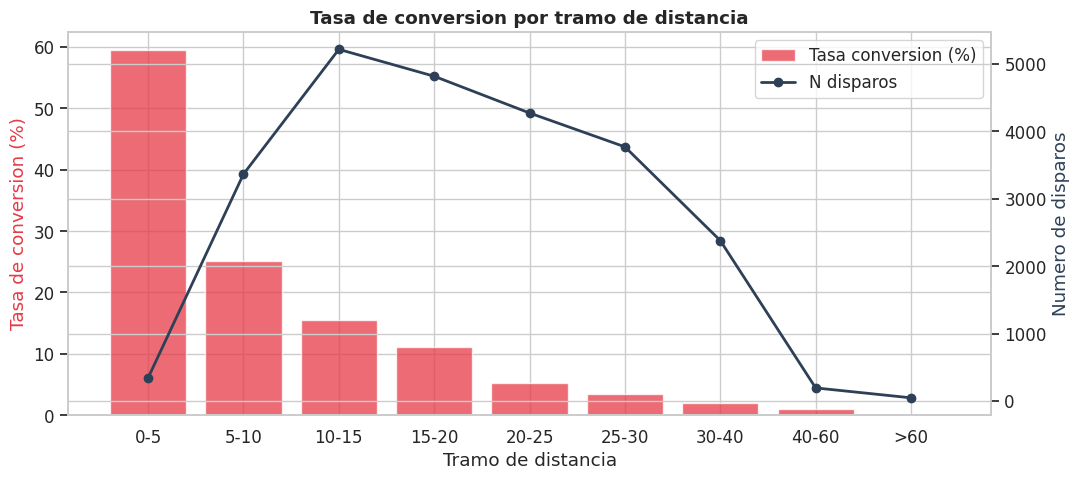

In [ ]:
df['distancia_tramo'] = pd.cut(df['shot_distance'],
    bins=[0,5,10,15,20,25,30,40,60,120],
    labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-40','40-60','>60'])

conv = df.groupby('distancia_tramo', observed=True)['gol'].agg(['mean','count']).reset_index()
conv.columns = ['tramo','tasa','n']
conv['tasa'] = conv['tasa'] * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.bar(conv['tramo'], conv['tasa'], color=COLORS['gol'], alpha=0.75, label='Tasa conversion (%)')
ax2.plot(conv['tramo'], conv['n'], 'o-', color=COLORS['neutral'], linewidth=2, markersize=6, label='N disparos')
ax1.set_xlabel('Tramo de distancia')
ax1.set_ylabel('Tasa de conversion (%)', color=COLORS['gol'])
ax2.set_ylabel('Numero de disparos', color=COLORS['neutral'])
ax1.set_title('Tasa de conversion por tramo de distancia', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
plt.tight_layout()
plt.savefig('conversion_por_distancia.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico muestra una relación inversa muy clara entre distancia y probabilidad de gol: los disparos desde menos de 5 metros tienen una tasa de conversión del 60%, que cae progresivamente hasta valores cercanos al 0% a partir de los 40 metros. El mayor volumen de disparos se concentra entre 10 y 30 metros, que es la zona de máxima actividad ofensiva. Esta relación no lineal justifica el uso de modelos de ML más flexibles que la regresión logística simple.

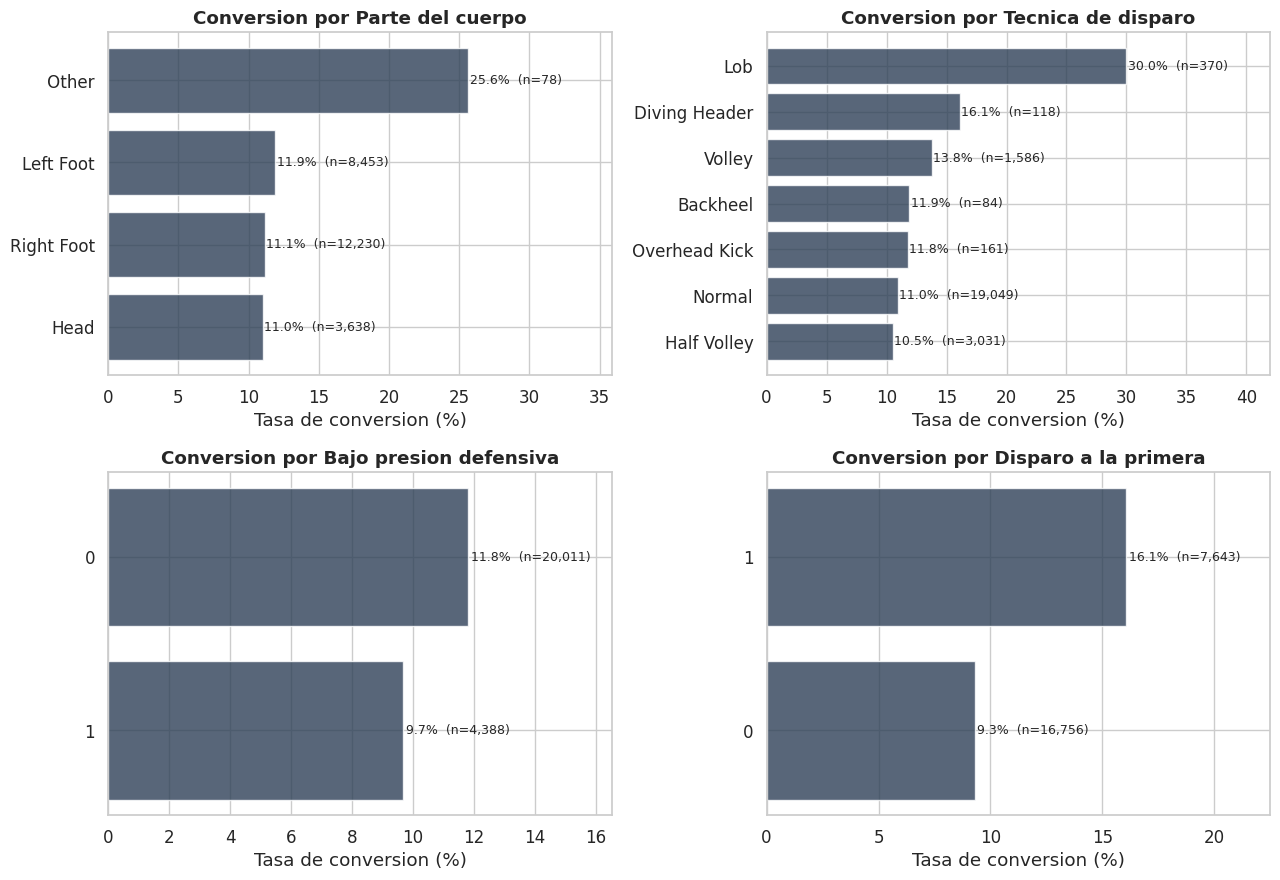

In [ ]:
vars_cat = [
    ('shot_body_part',  'Parte del cuerpo'),
    ('shot_technique',  'Tecnica de disparo'),
    ('under_pressure',  'Bajo presion defensiva'),
    ('shot_first_time', 'Disparo a la primera')
]
vars_cat = [(v,l) for v,l in vars_cat if v in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (var, label) in enumerate(vars_cat):
    tabla = df.groupby(var)['gol'].agg(['mean','count']).reset_index()
    tabla.columns = [var,'tasa','n']
    tabla['tasa'] = tabla['tasa'] * 100
    tabla = tabla.sort_values('tasa', ascending=True)
    bars = axes[i].barh(tabla[var].astype(str), tabla['tasa'],
                        color=COLORS['neutral'], alpha=0.8, edgecolor='white')
    for bar, n in zip(bars, tabla['n']):
        axes[i].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                     f'{bar.get_width():.1f}%  (n={n:,})', va='center', fontsize=9)
    axes[i].set_xlabel('Tasa de conversion (%)')
    axes[i].set_title(f'Conversion por {label}', fontweight='bold')
    axes[i].set_xlim(0, tabla['tasa'].max() * 1.4)

plt.tight_layout()
plt.savefig('conversion_variables_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

Los resultados muestran diferencias importantes entre diferentes grupos. En cuanto a la técnica, el lob es la opción que más éxito tiene, con un porcentaje de acierto del 30%, mucho más alto que la media habitual del 11%. Sobre las partes del cuerpo, las diferencias son menores de lo que se esperaba, aunque el pie izquierdo consigue un poco más de aciertos que el derecho. La presión del equipo que defiende hace que la tasa de éxito disminuya del 11.8% al 9.7%. Además, los tiros que se hacen a la primera tienen más posibilidades de ser efectivos (16.1%) en comparación con aquellos en los que se tiene que controlar el balón antes de tirar (9.3%). Esto indica que la sorpresa puede ser un factor importante para conseguir el gol.

In [ ]:
def detectar_outliers_iqr(serie, k=1.5):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (serie < lower) | (serie > upper), lower, upper

print('Analisis de outliers (metodo IQR, k=1.5):')
print('=' * 50)
for var in ['shot_distance', 'shot_angle', 'minute']:
    if var not in df.columns:
        continue
    mask, lower, upper = detectar_outliers_iqr(df[var].dropna())
    print(f'\n{var}:')
    print(f'  Limite inferior: {lower:.2f}')
    print(f'  Limite superior: {upper:.2f}')
    print(f'  Outliers: {mask.sum():,} ({mask.sum()/len(df)*100:.2f}%)')
    print(f'  Decision: se conservan (disparos reales y validos)')

Analisis de outliers (metodo IQR, k=1.5):

shot_distance:
  Limite inferior: -7.25
  Limite superior: 44.88
  Outliers: 152 (0.62%)
  Decision: se conservan (disparos reales y validos)

shot_angle:
  Limite inferior: -7.89
  Limite superior: 53.00
  Outliers: 1,523 (6.24%)
  Decision: se conservan (disparos reales y validos)

minute:
  Limite inferior: -41.50
  Limite superior: 138.50
  Outliers: 0 (0.00%)
  Decision: se conservan (disparos reales y validos)


Se usa un método llamado rango intercuartílico (IQR) para identificar valores extraños en las tres variables principales. En la distancia, se encuentran 152 casos atípicos (0,62%), que corresponden a disparos desde lugares muy lejanos; en el ángulo, aparecen 1.523 casos (6,24%), que representan disparos desde posiciones muy laterales; y en el minuto del partido, no hay ninguno. En todos los casos, se decide mantener estos datos porque son eventos reales y importantes del partido. Quitar estos datos significaría perder información válida sobre disparos que, aunque poco comunes, sucedieron de verdad.

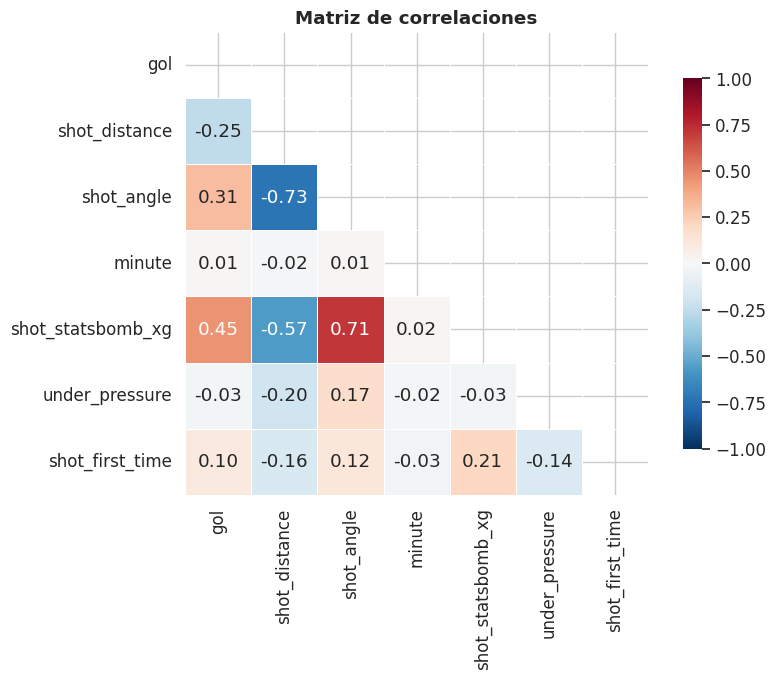


Correlaciones con la variable objetivo (gol):
shot_statsbomb_xg    0.4460
shot_angle           0.3090
shot_first_time      0.0990
minute               0.0090
under_pressure      -0.0260
shot_distance       -0.2530


In [ ]:
vars_corr = ['gol','shot_distance','shot_angle','minute',
             'shot_statsbomb_xg','under_pressure','shot_first_time']
vars_corr = [v for v in vars_corr if v in df.columns]

corr_matrix = df[vars_corr].corr().round(3)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlaciones', fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelaciones con la variable objetivo (gol):')
print(corr_matrix['gol'].drop('gol').sort_values(ascending=False).to_string())

La tabla muestra que la probabilidad que estima StatsBomb para un disparo terminar en gol (llamada xG) es la más relacionada con que el disparo sea efectivo, con un valor de 0.45. Esto tiene sentido, porque esa probabilidad ya calcula algo sobre qué tan probable es que el disparo sea gol. Después, están el ángulo del disparo (el ángulo con respecto a la portería), que tiene una relación de 0.31, y la distancia a la portería, que tiene una relación de -0.25. Esto significa que a mayor ángulo y menor distancia, aumenta la probabilidad de que el disparo sea gol, como se esperaba.
El minuto en el que se realiza el disparo (el momento del partido) no tiene mucha relación con si termina en gol (valor 0.01), lo que sugiere que el tiempo en el partido no influye en el resultado del disparo.
También se observa que la distancia y el ángulo están bastante relacionadas entre sí (valor -0.73). Esto indica que ambos miden algo parecido, por lo que hay que tener cuidado al usarlos en modelos, para no repetir la misma información.

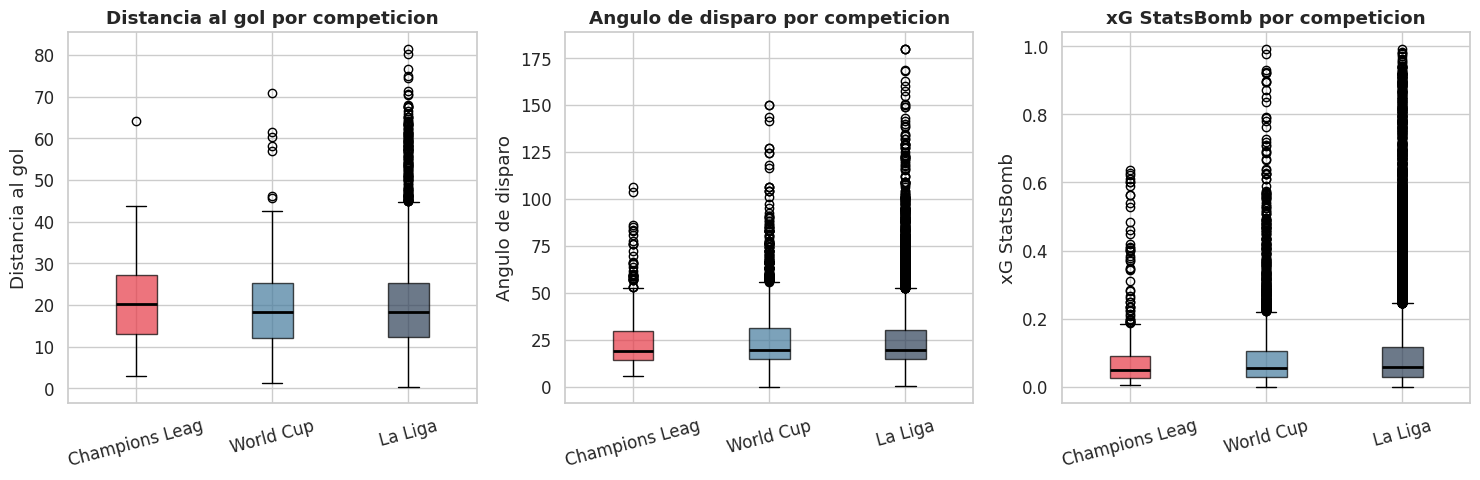

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = [
    ('shot_distance',    'Distancia al gol'),
    ('shot_angle',       'Angulo de disparo'),
    ('shot_statsbomb_xg','xG StatsBomb')
]
comps = df['competition'].unique()
colors_list = [COLORS['gol'], COLORS['no_gol'], COLORS['neutral']]

for i, (var, label) in enumerate(metricas):
    if var not in df.columns:
        continue
    data_plot = [df[df['competition']==c][var].dropna().values for c in comps]
    short_labels = [c.replace('UEFA ','').replace('FIFA ','')[:14] for c in comps]
    bp = axes[i].boxplot(data_plot, labels=short_labels, patch_artist=True,
                         medianprops={'color':'black','linewidth':2})
    for box, color in zip(bp['boxes'], colors_list):
        box.set_facecolor(color)
        box.set_alpha(0.7)
    axes[i].set_title(f'{label} por competicion', fontweight='bold')
    axes[i].set_ylabel(label)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('comparativa_por_competicion.png', dpi=150, bbox_inches='tight')
plt.show()

Los boxplots muestran que la forma en que se hacen los disparos es muy parecida en las tres competiciones, tanto en la distancia como en el ángulo, ya que las medians son muy similares. La mayor diferencia se nota en el promedio de las probabilidades de gol esperadas (xG), donde la Champions League tiene valores un poco más bajos. Esto sugiere que los disparos en esa competición suelen ser en situaciones un poco menos favorables. En general, la similitud entre las competiciones es una buena señal para el modelo, porque significa que lo que aprende en una competición puede aplicarse también a las demás.

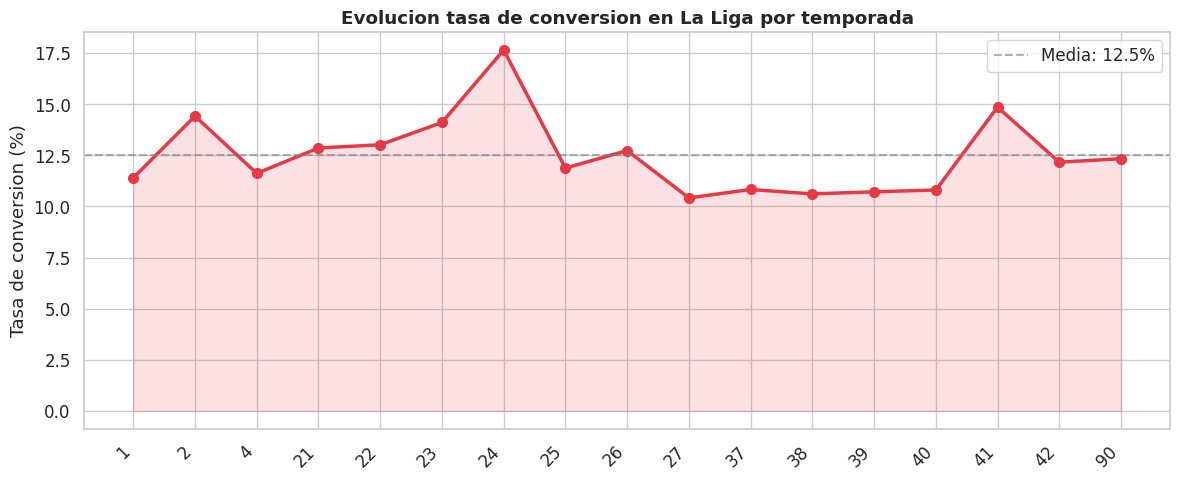

In [ ]:
la_liga = df[df['competition'] == 'La Liga'].copy()
if len(la_liga) > 0:
    evolucion = la_liga.groupby('season_id')['gol'].agg(['mean','count']).reset_index()
    evolucion.columns = ['season_id','tasa','n']
    evolucion['tasa'] = evolucion['tasa'] * 100
    evolucion = evolucion.sort_values('season_id')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(evolucion)), evolucion['tasa'],
            'o-', color=COLORS['gol'], linewidth=2.5, markersize=7)
    ax.fill_between(range(len(evolucion)), evolucion['tasa'],
                    alpha=0.15, color=COLORS['gol'])
    ax.set_xticks(range(len(evolucion)))
    ax.set_xticklabels(evolucion['season_id'], rotation=45, ha='right')
    ax.set_ylabel('Tasa de conversion (%)')
    ax.set_title('Evolucion tasa de conversion en La Liga por temporada', fontweight='bold')
    media = evolucion['tasa'].mean()
    ax.axhline(media, color='gray', linestyle='--', alpha=0.6, label=f'Media: {media:.1f}%')
    ax.legend()
    plt.tight_layout()
    plt.savefig('evolucion_temporal_laliga.png', dpi=150, bbox_inches='tight')
    plt.show()

La tasa de conversión en La Liga ha sido bastante constante a lo largo de las 17 temporadas que se analizaron, con un promedio de aproximadamente 12.5%. En algunos momentos, hubo pequeñas variaciones, y en una temporada en particular el porcentaje subió por encima del 17%. Sin embargo, no hay una tendencia clara de que aumente o disminuya con el tiempo. Esto indica que el rendimiento ofensivo en el fútbol de alto nivel suele mantenerse bastante estable, lo que apoya la idea de que es útil entrenar modelos con datos de varias temporadas para obtener resultados confiables.

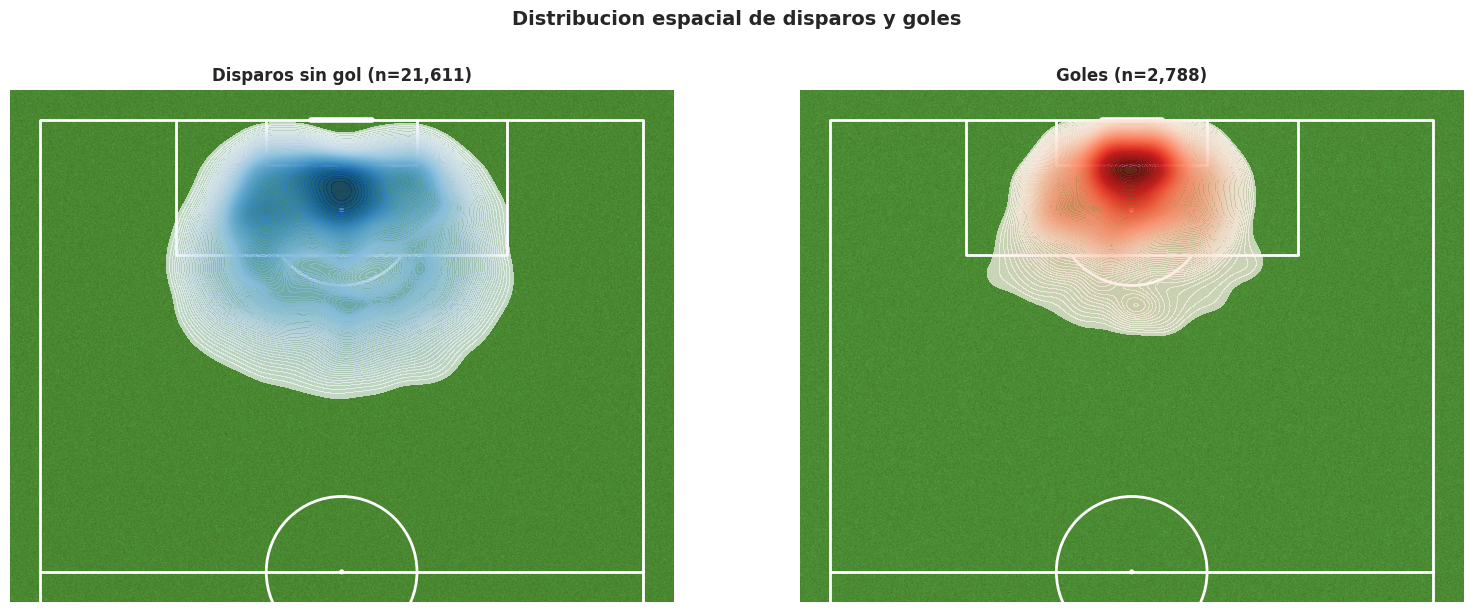

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, (resultado, titulo, cmap) in enumerate([
    (0, 'Disparos sin gol', 'Blues'),
    (1, 'Goles',            'Reds')
]):
    subset = df[df['gol'] == resultado]
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='grass',
                          line_color='white', half=True)
    pitch.draw(ax=axes[i])
    pitch.kdeplot(subset['x'], subset['y'], ax=axes[i],
                  fill=True, levels=100, cmap=cmap, alpha=0.7)
    axes[i].set_title(f'{titulo} (n={len(subset):,})', fontweight='bold', fontsize=12)

plt.suptitle('Distribucion espacial de disparos y goles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mapa_disparos_campo.png', dpi=150, bbox_inches='tight')
plt.show()

Los mapas de calor sobre el campo muestran claramente en forma visual la diferencia entre donde se realizan los disparos y donde se marcan los goles. Los disparos que no entraron en la portería están distribuidos en una zona extensa delante del área, mientras que los goles están muy concentrados en la parte central del área pequeña, justo frente a la portería. Esta agrupación de los goles en un lugar específico es una de las pruebas más evidentes de que la posición desde donde se dispara es el factor más importante en el modelo xG.

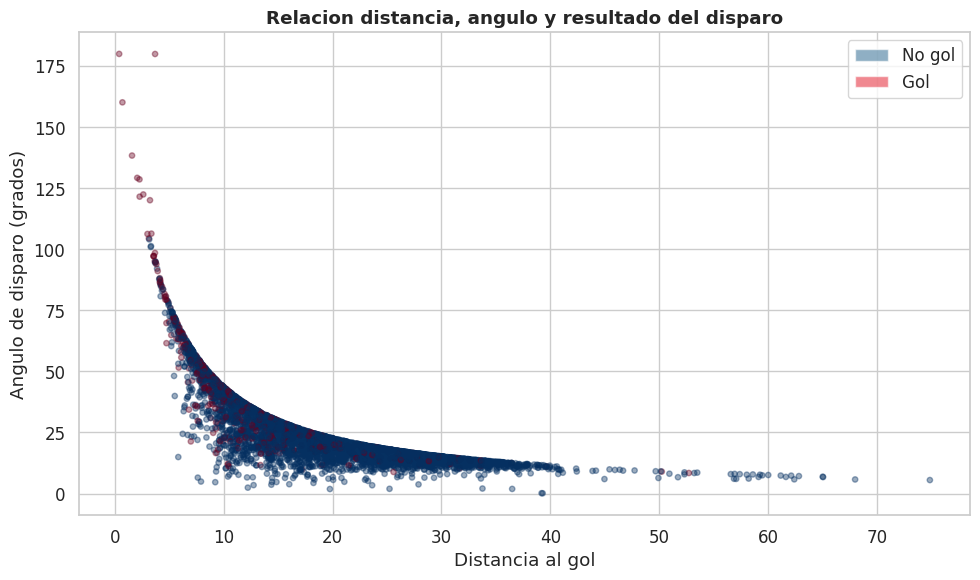

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df.sample(min(5000, len(df)), random_state=42)
ax.scatter(sample['shot_distance'], sample['shot_angle'],
           c=sample['gol'], cmap='RdBu_r', alpha=0.4, s=15, vmin=0, vmax=1)
legend_elements = [
    mpatches.Patch(facecolor=COLORS['no_gol'], alpha=0.6, label='No gol'),
    mpatches.Patch(facecolor=COLORS['gol'],    alpha=0.6, label='Gol')
]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlabel('Distancia al gol')
ax.set_ylabel('Angulo de disparo (grados)')
ax.set_title('Relacion distancia, angulo y resultado del disparo', fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_distancia_angulo_gol.png', dpi=150, bbox_inches='tight')
plt.show()

El scatter plot muestra cómo se relacionan la distancia y el ángulo en una muestra de 5.000 disparos. Se puede ver que, generalmente, cuanto más lejos está el disparo, menor es el ángulo en el que se realiza. Esto ya lo habíamos notado antes al analizar las relaciones entre las variables. Los goles, marcados en rojo, están en su mayoría en lugares cercanos y con un ángulo más centrado, lo que indica que las mejores oportunidades de marcar suelen ocurrir cuando se está cerca y en una posición más frontal. A partir de los 20 metros de distancia, es muy difícil que el disparo termine en gol, sin importar el ángulo en el que se realice.

In [ ]:
print('=' * 65)
print('RESUMEN DEL ANALISIS EXPLORATORIO DE DATOS (EDA)')
print('=' * 65)
print(f"""
VOLUMEN
   Disparos totales (sin penaltis): {len(df):,}
   Goles: {df['gol'].sum():,} ({df['gol'].mean()*100:.1f}%)
   Ratio desbalance: {df['gol'].value_counts()[0]/df['gol'].value_counts()[1]:.1f}:1

DISTANCIA Y ANGULO
   Distancia media goles:    {df[df['gol']==1]['shot_distance'].mean():.1f}
   Distancia media no goles: {df[df['gol']==0]['shot_distance'].mean():.1f}
   Angulo medio goles:       {df[df['gol']==1]['shot_angle'].mean():.1f} grados
   Angulo medio no goles:    {df[df['gol']==0]['shot_angle'].mean():.1f} grados
""")

df.to_csv('dataset_disparos_limpio.csv', index=False)
print('Dataset guardado como dataset_disparos_limpio.csv')

RESUMEN DEL ANALISIS EXPLORATORIO DE DATOS (EDA)

VOLUMEN
   Disparos totales (sin penaltis): 24,399
   Goles: 2,788 (11.4%)
   Ratio desbalance: 7.8:1

DISTANCIA Y ANGULO
   Distancia media goles:    13.1
   Distancia media no goles: 20.0
   Angulo medio goles:       38.4 grados
   Angulo medio no goles:    23.2 grados

Dataset guardado como dataset_disparos_limpio.csv


El EDA concluye con un resumen de los aspectos más importantes que se encontraron. En el conjunto de datos, hay 24.399 tiros realizados en partidos abiertos. De estos, solo el 11.4% terminaron en gol. Además, hay un desequilibrio importante entre los tiros que fueron goles y los que no, con una proporción de 7.8 a 1. Por otro lado, la distancia promedio de los tiros que terminaron en gol fue de 13.1 metros, mucho menor que la distancia de los tiros que no fueron goles, que fue de 20 metros. También, el ángulo medio desde el que se realizaron los tiros que lograron gol fue de 38.4 grados, mayor que el de los tiros fallidos, que fue de 23.2 grados. Esto muestra que estas dos variables, la distancia y el ángulo, son las más importantes para predecir si un tiro será gol o no. Finalmente, los datos limpios se guardarán en un archivo llamado "dataset_disparos_limpio.csv" para ser utilizados en las próximas etapas del análisis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/TFM/'

# Guardar dataset principal
df.to_csv(ruta + 'dataset_disparos_limpio.csv', index=False)
print('dataset_disparos_limpio.csv guardado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset_disparos_limpio.csv guardado.
